# ALICE HEPData plots

This notebook loads the CSV tables you uploaded from the ALICE dataset and plots each table.

It:
- reads the HEPData metadata stored in the commented header lines
- detects the x and y columns
- plots the central values
- adds statistical error bars
- overlays systematic uncertainties when available


In [24]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("10.17182/HEPData-ins1759506-v1-csv/")
TABLE_FILES = sorted(DATA_DIR.glob("Table*.csv"))

print("Found files:")
for f in TABLE_FILES:
    print("-", f.name)


tables = {}

for path in TABLE_FILES:
    metadata, df = read_hepdata_csv(path)
    tables[path.name] = {"metadata": metadata, "df": df}

Found files:
- Table01.csv
- Table02.csv
- Table03.csv
- Table04.csv
- Table05.csv
- Table06.csv
- Table07.csv
- Table08.csv
- Table09.csv
- Table10.csv
- Table11.csv
- Table12.csv
- Table13.csv
- Table14.csv
- Table15.csv
- Table16.csv
- Table17.csv


In [25]:
summary_rows = []

for path in TABLE_FILES:
    name = path.name
    item = tables[name]

    metadata = item["metadata"]
    df = item["df"]

    summary_rows.append({
        "file": name,
        "title": metadata.get("name", ""),
        "description": metadata.get("description", ""),
        "rows": len(df),
        "columns": len(df.columns),
        "doi": metadata.get("table_doi", "")
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,title,description,rows,columns,doi
0,Table01.csv,Table 1,$p_{T}$-distributions of pions ($\pi^{+}+\pi^{...,589,10,10.17182/hepdata.104923.v1/t1
1,Table02.csv,Table 2,$p_{T}$-distributions of pions ($\pi^{+}+\pi^{...,58,8,10.17182/hepdata.104923.v1/t2
2,Table03.csv,Table 3,$p_{T}$-distributions of kaons ($K^{+}+K^{-}$)...,539,10,10.17182/hepdata.104923.v1/t3
3,Table04.csv,Table 4,$p_{T}$-distributions of kaons ($K^{+}+K^{-}$)...,53,8,10.17182/hepdata.104923.v1/t4
4,Table05.csv,Table 5,$p_{T}$-distributions of protons ($p+pbar$) me...,519,10,10.17182/hepdata.104923.v1/t5
5,Table06.csv,Table 6,$p_{T}$-distributions of protons ($p+pbar$) me...,51,8,10.17182/hepdata.104923.v1/t6
6,Table07.csv,Table 7,$p_{T}$-distributions of kaons ($K^{+}+K^{-}$)...,539,10,10.17182/hepdata.104923.v1/t7
7,Table08.csv,Table 8,$p_{T}$-distributions of kaons ($K^{+}+K^{-}$)...,53,8,10.17182/hepdata.104923.v1/t8
8,Table09.csv,Table 9,$p_{T}$-distributions of protons ($p+pbar$)/pi...,519,10,10.17182/hepdata.104923.v1/t9
9,Table10.csv,Table 10,$p_{T}$-distributions of protons ($p+pbar$)/pi...,51,8,10.17182/hepdata.104923.v1/t10


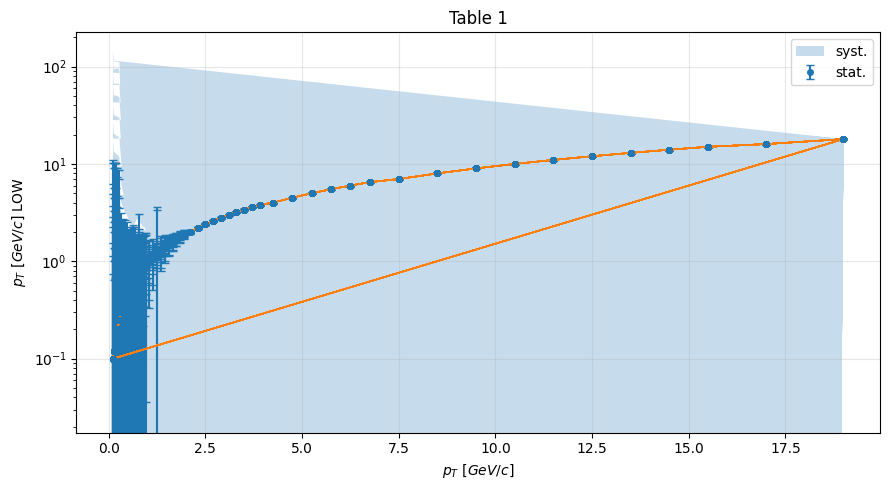

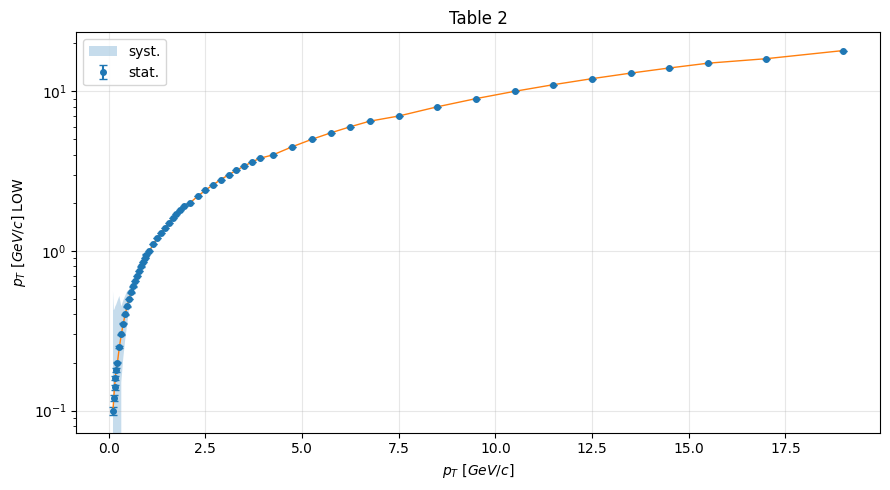

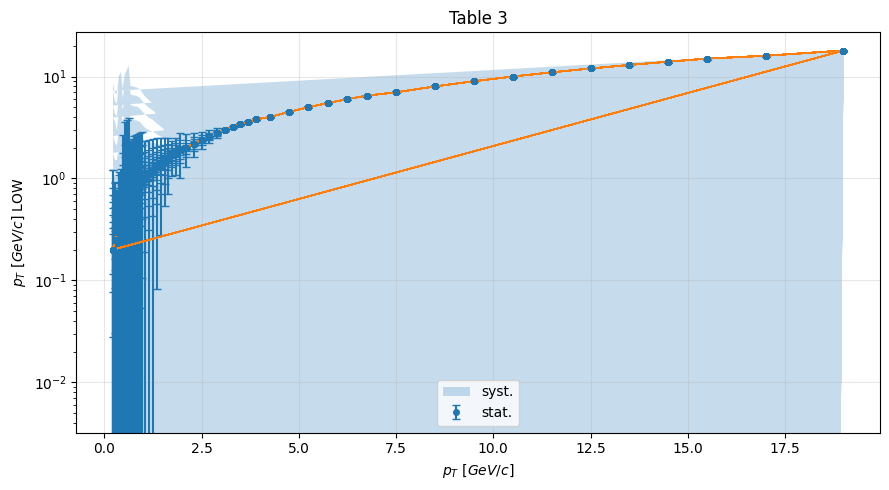

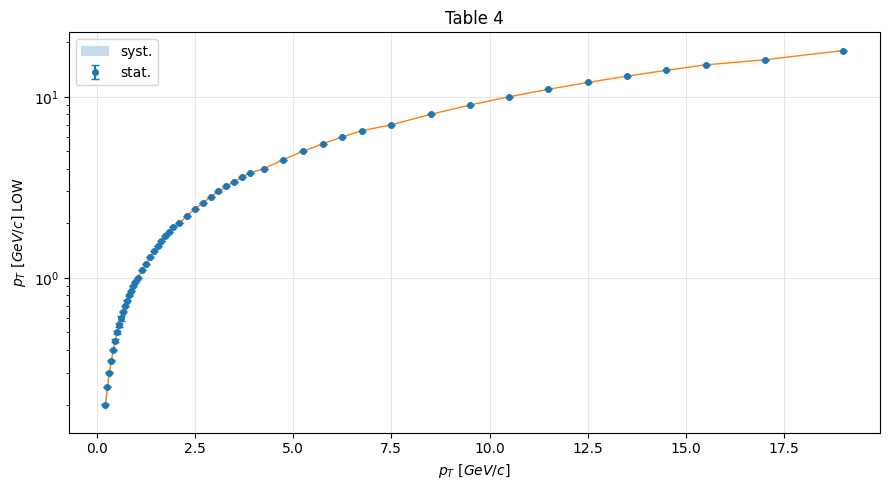

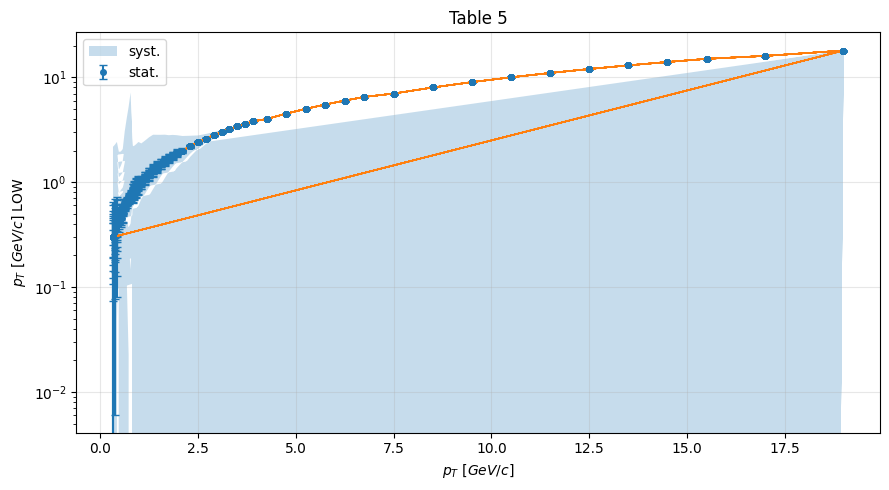

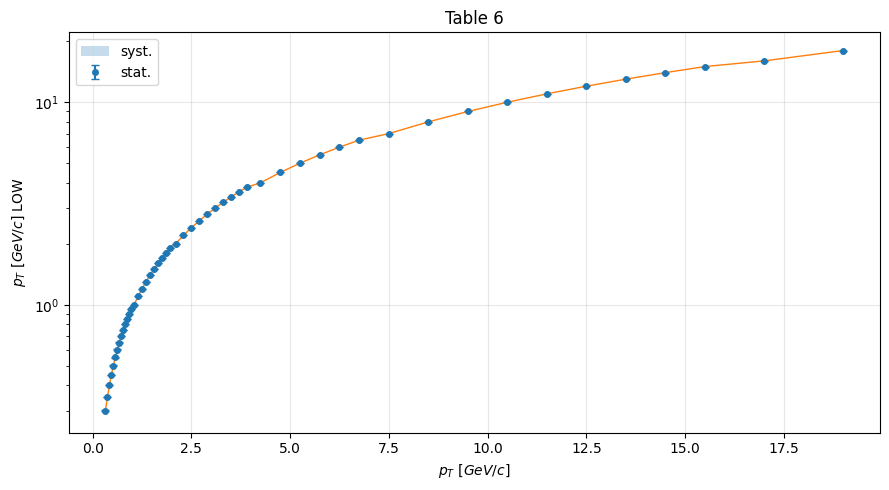

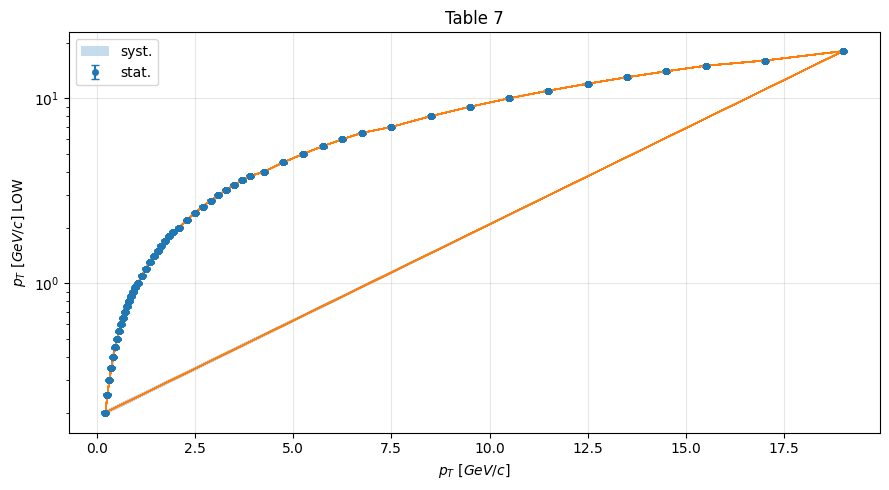

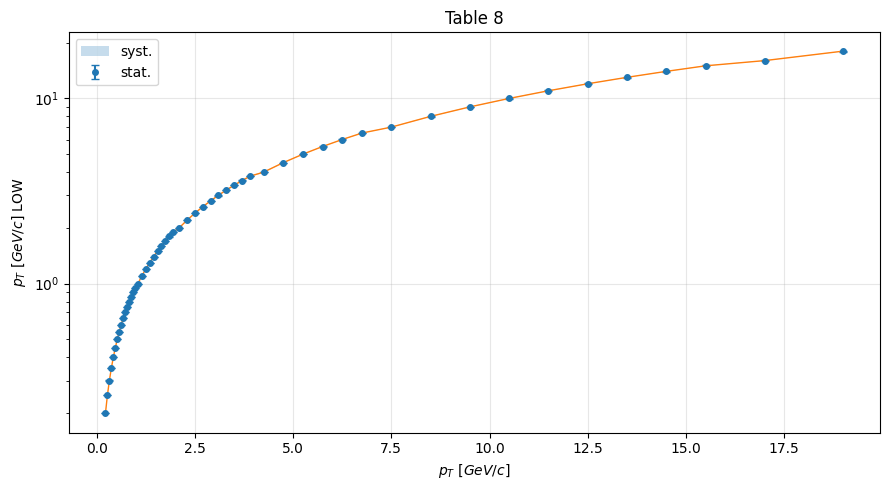

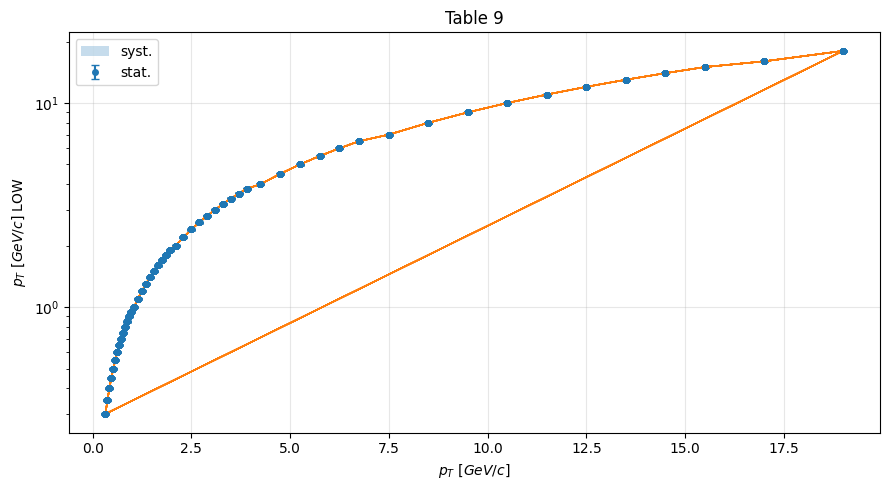

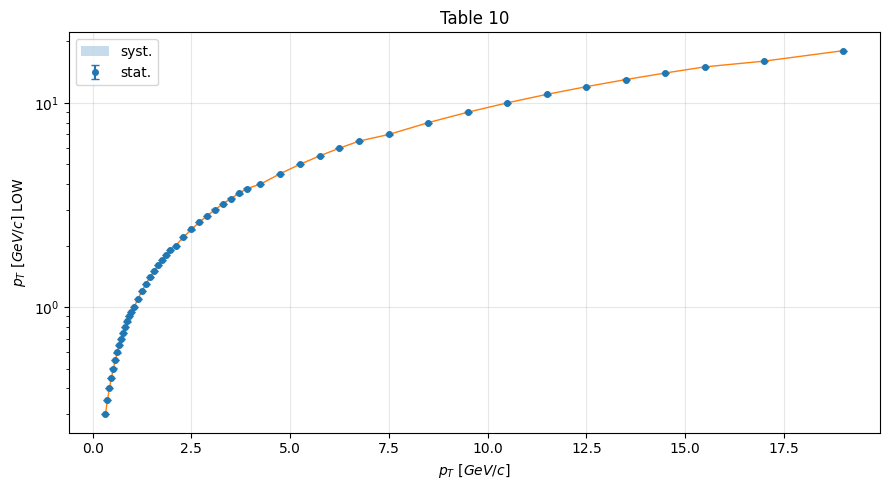

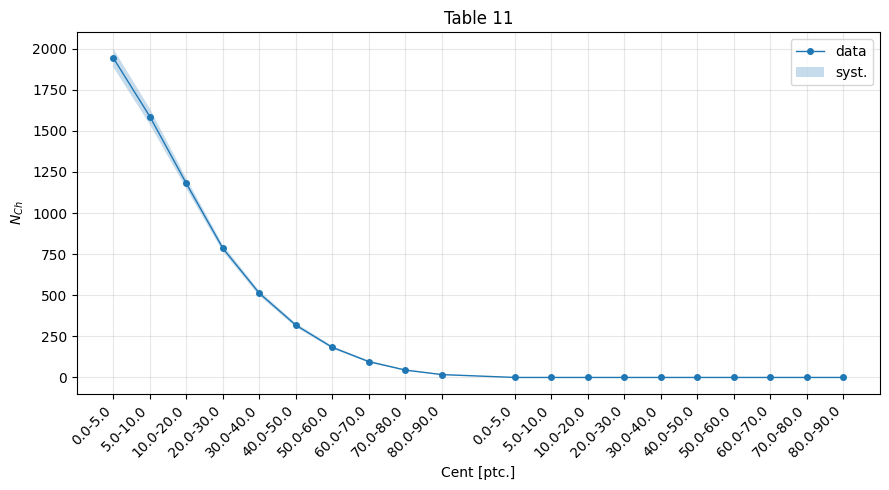

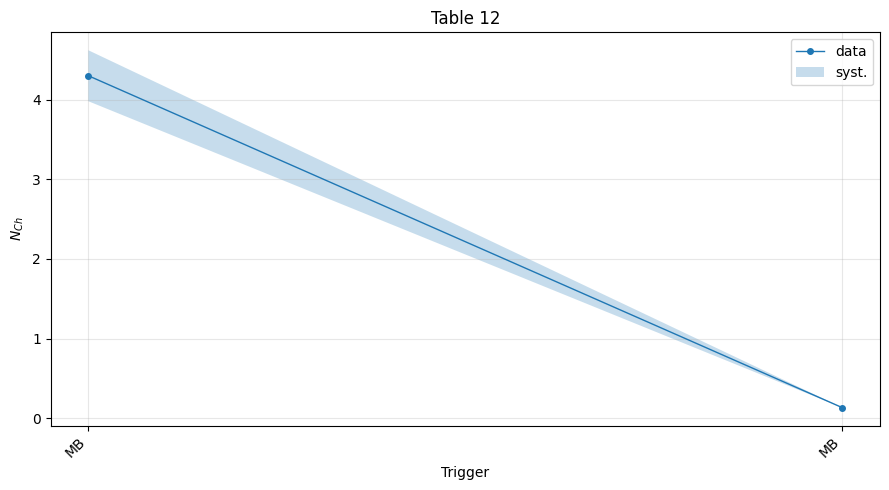

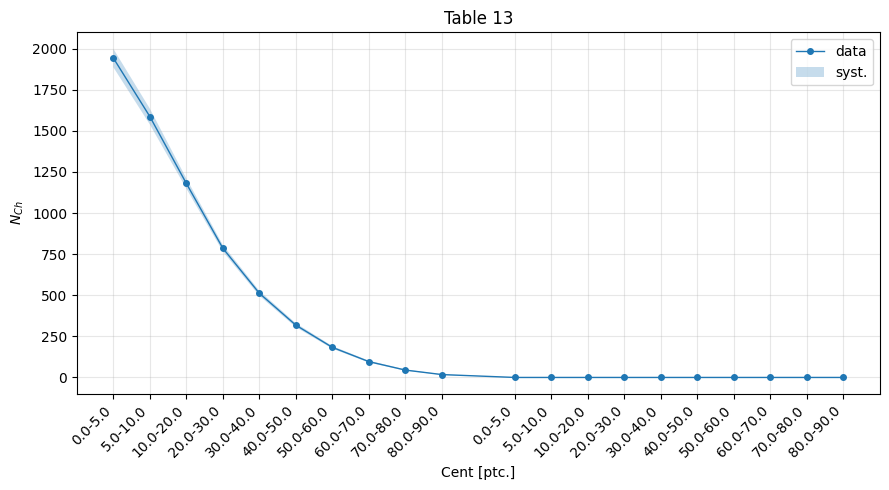

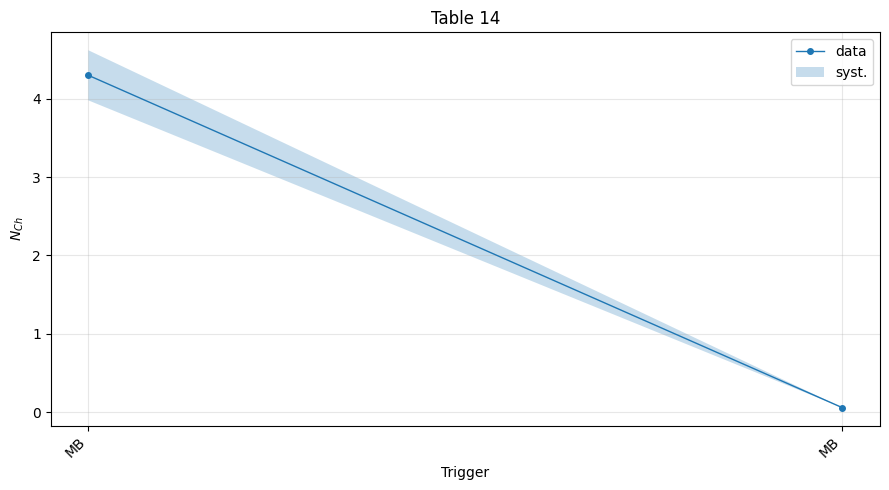

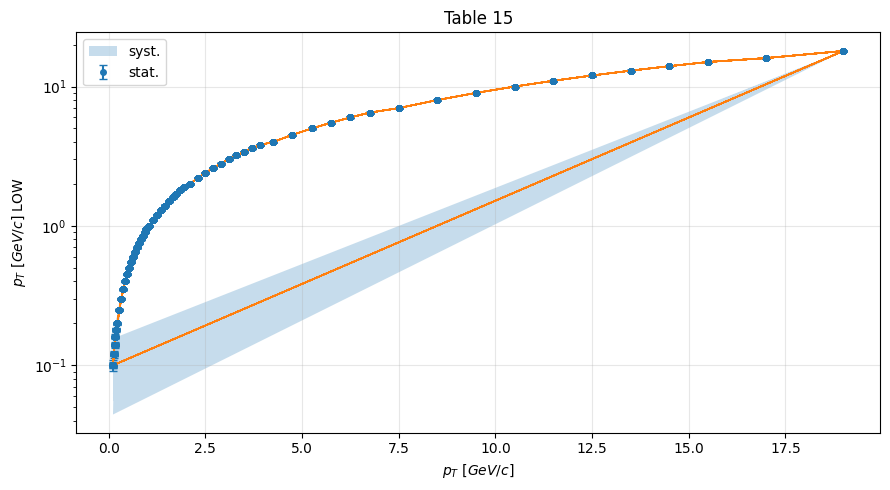

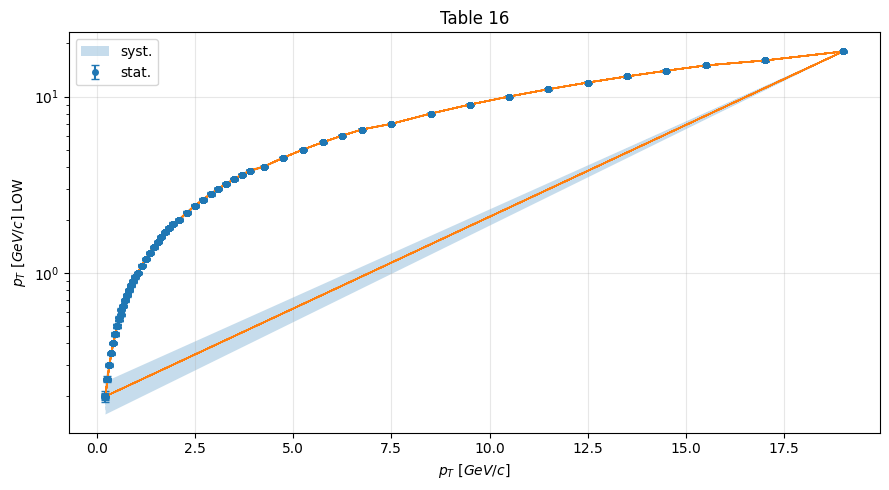

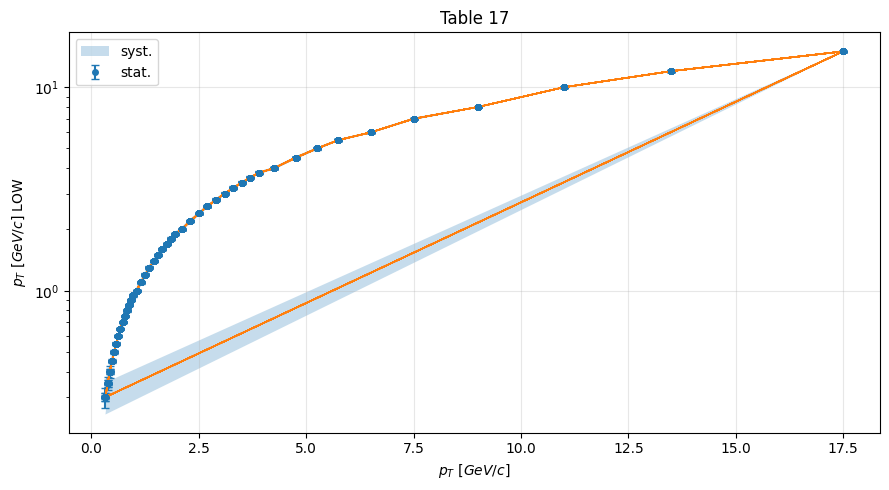

In [28]:
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def find_x_y_columns(df):
    cols = list(df.columns)
    lowers = {c: c.lower() for c in cols}

    # 1) tabelas diferenciais em pT
    pt_cols = [c for c in cols if "p_{t}" in lowers[c] or "pt" in lowers[c]]
    if pt_cols:
        xcol = pt_cols[0]
        for c in cols:
            if c == xcol:
                continue
            low = lowers[c]
            if "stat" in low or "syst" in low:
                continue
            return xcol, c

    # 2) tabelas categóricas com Nch
    nch_cols = [c for c in cols if "n_{ch}" in lowers[c]]
    if nch_cols:
        ycol = nch_cols[0]
        for c in cols:
            if c == ycol:
                continue
            low = lowers[c]
            if "stat" in low or "syst" in low:
                continue
            return c, ycol

    # fallback
    non_err = [c for c in cols if "stat" not in lowers[c] and "syst" not in lowers[c]]
    if len(non_err) >= 2:
        return non_err[0], non_err[1]
    elif len(non_err) == 1:
        return non_err[0], non_err[0]
    else:
        return cols[0], cols[min(1, len(cols)-1)]
    
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

for name, item in tables.items():
    metadata = item["metadata"]
    df = item["df"].copy()

    xcol, ycol = find_x_y_columns(df)

    stat_plus = get_uncertainty_column(df, "stat. +")
    syst_plus = get_uncertainty_column(df, "syst. +")

    # tenta interpretar x como numérico
    x_num = to_num(df[xcol])
    y = to_num(df[ycol])

    is_categorical_x = x_num.notna().sum() == 0

    if is_categorical_x:
        x_labels = df[xcol].astype(str)
        x = pd.Series(range(len(df)), index=df.index)
    else:
        x = x_num
        x_labels = None

    mask = x.notna() & y.notna()
    x_plot = x[mask]
    y_plot = y[mask]

    if len(x_plot) == 0 or len(y_plot) == 0:
        print(f"{name}: sem dados numéricos válidos para plotar.")
        print("Colunas disponíveis:", list(df.columns))
        print("xcol detectada:", xcol)
        print("ycol detectada:", ycol)
        continue

    yerr_stat = None
    if stat_plus is not None:
        yerr_stat = to_num(df.loc[mask, stat_plus]).abs()

    yerr_syst = None
    if syst_plus is not None:
        yerr_syst = to_num(df.loc[mask, syst_plus]).abs()

    fig, ax = plt.subplots(figsize=(9, 5))

    if yerr_stat is not None and yerr_stat.notna().any():
        good_stat = yerr_stat.notna()
        ax.errorbar(
            x_plot[good_stat],
            y_plot[good_stat],
            yerr=yerr_stat[good_stat],
            fmt="o",
            markersize=4,
            capsize=3,
            label="stat."
        )
        ax.plot(x_plot, y_plot, linewidth=1)
    else:
        ax.plot(x_plot, y_plot, "o-", markersize=4, linewidth=1, label="data")

    if yerr_syst is not None and yerr_syst.notna().any():
        low = y_plot - yerr_syst
        high = y_plot + yerr_syst
        good_syst = low.notna() & high.notna()
        ax.fill_between(
            x_plot[good_syst],
            low[good_syst],
            high[good_syst],
            alpha=0.25,
            label="syst."
        )

    ax.set_title(metadata.get("name", name))
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # só usar log para tabelas diferenciais com y positivo e x numérico
    if (not is_categorical_x) and (y_plot > 0).all():
        desc = str(metadata.get("description", "")).lower()
        if "integrated" not in desc and "ratio" not in desc:
            ax.set_yscale("log")

    if is_categorical_x:
        labels = x_labels[mask]
        ax.set_xticks(list(x_plot))
        ax.set_xticklabels(labels, rotation=45, ha="right")

    fig.tight_layout()
    plt.show()

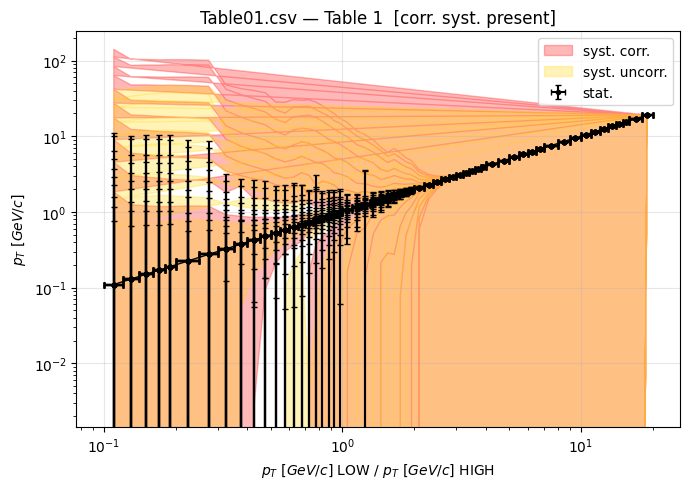

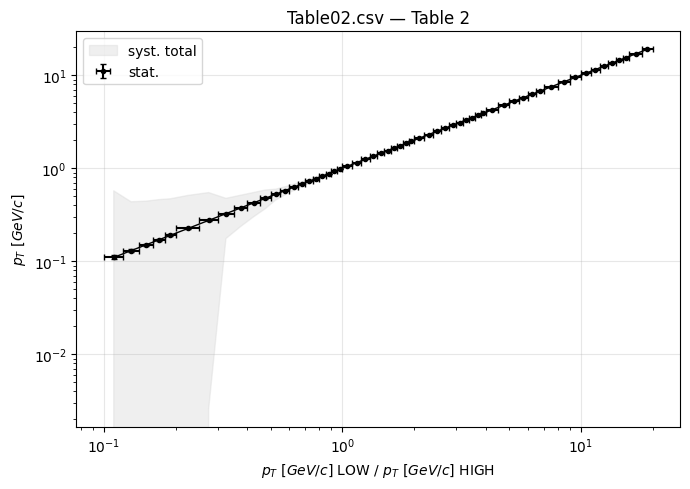

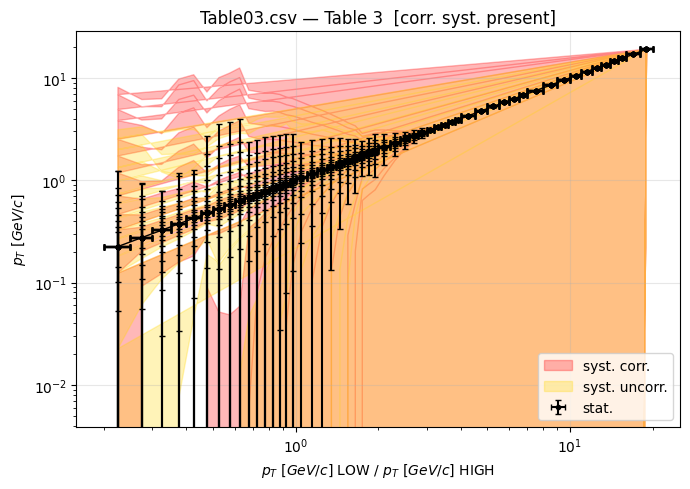

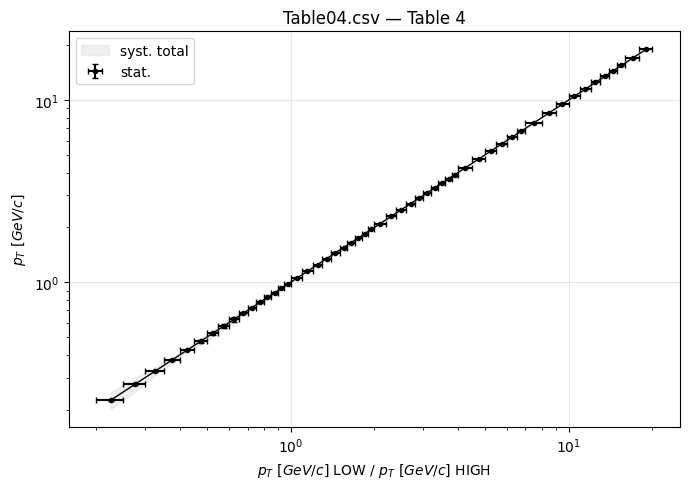

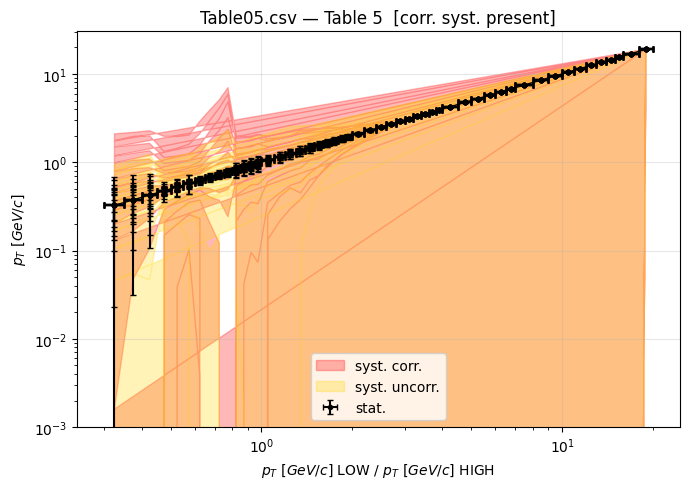

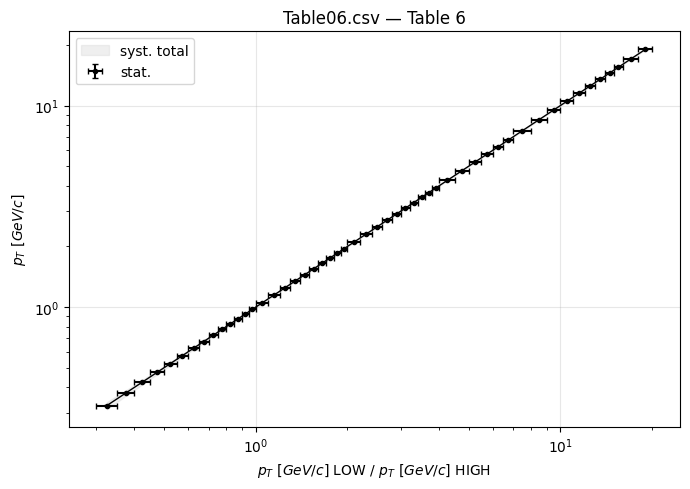

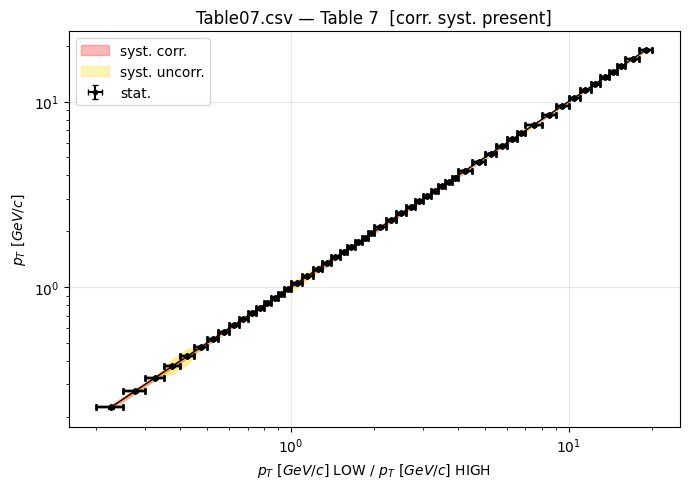

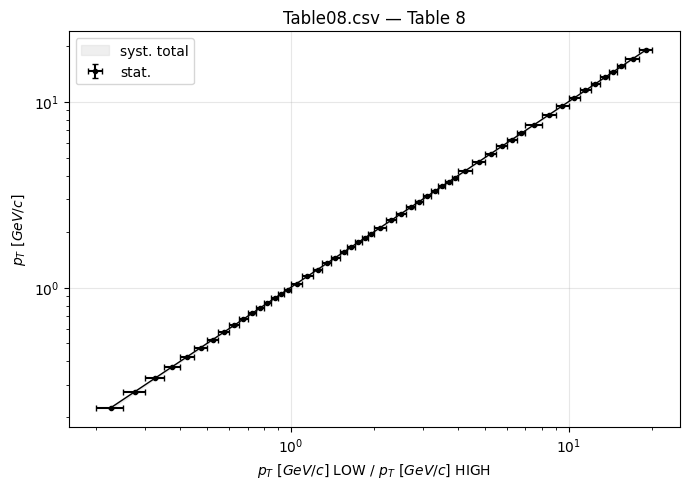

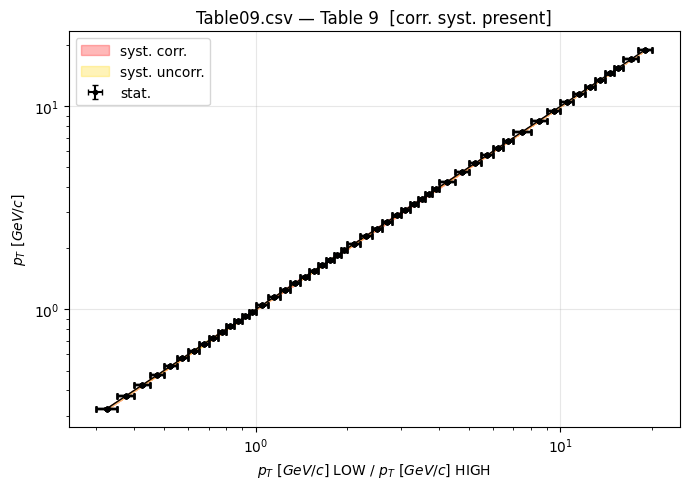

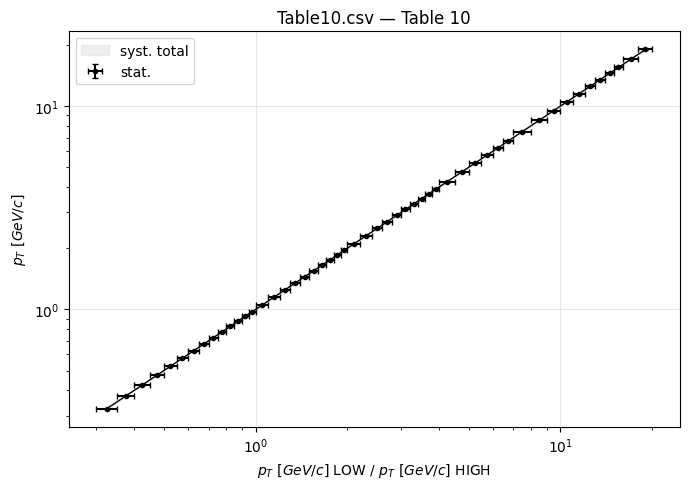

Table11.csv: sem dados numéricos válidos.
Colunas: ['Cent [ptc.]', '$N_{Ch}$', 'syst. +', 'syst. -']


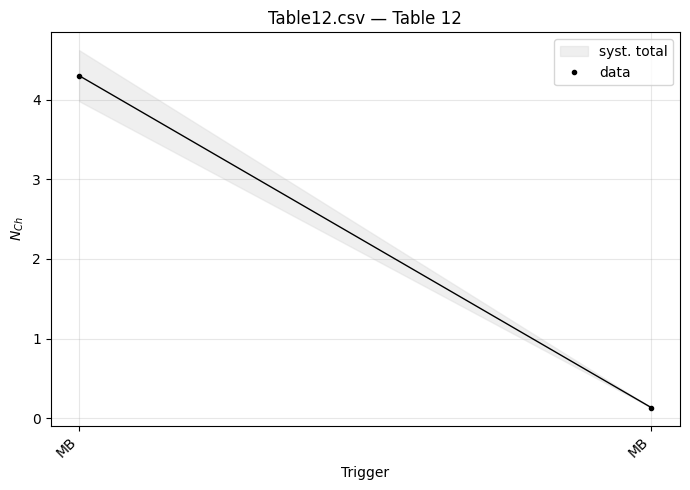

Table13.csv: sem dados numéricos válidos.
Colunas: ['Cent [ptc.]', '$N_{Ch}$', 'syst. +', 'syst. -']


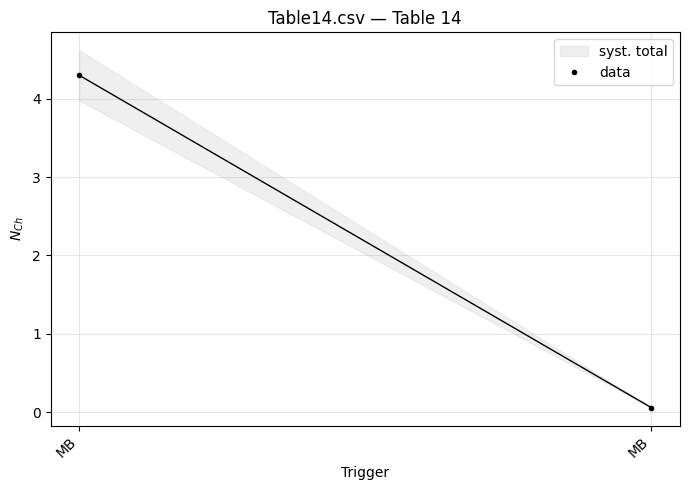

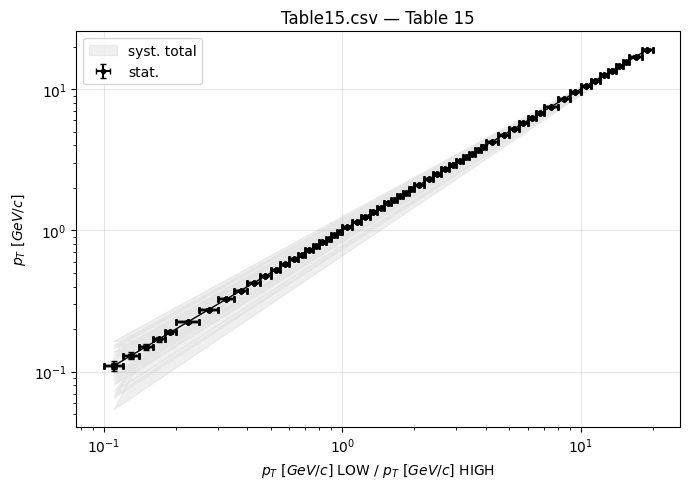

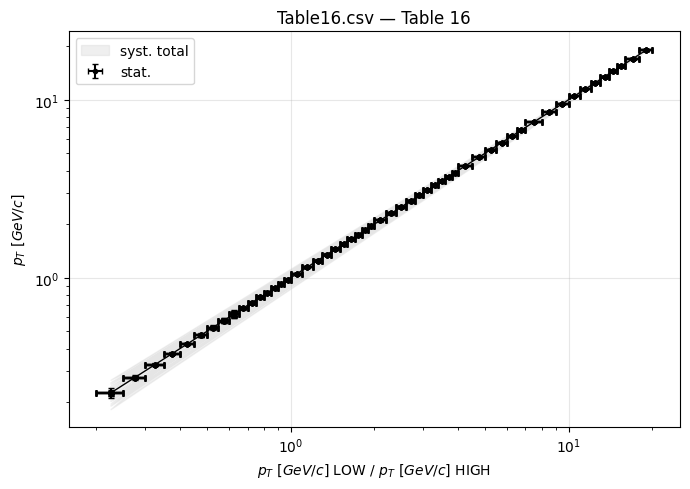

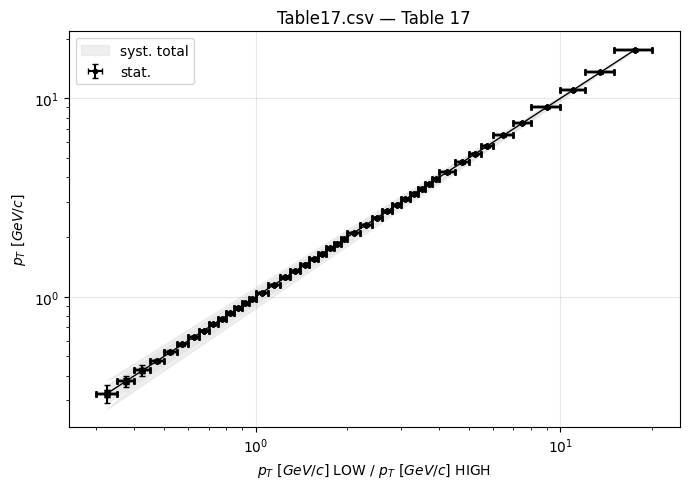

In [29]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def to_num(s):
    return pd.to_numeric(s, errors="coerce")


def get_uncertainty_column(df, target):
    for col in df.columns:
        if col.strip().lower() == target.strip().lower():
            return col
    return None


def natural_table_key(name):
    m = re.search(r"Table0*([0-9]+)", name)
    return int(m.group(1)) if m else 10**9


def find_x_y_columns(df):
    cols = list(df.columns)
    lowers = {c: c.lower() for c in cols}

    # caso 1: tabelas diferenciais em pT com LOW/HIGH
    low_cols = [c for c in cols if "low" in lowers[c]]
    high_cols = [c for c in cols if "high" in lowers[c]]

    if low_cols and high_cols:
        x_low = low_cols[0]
        x_high = high_cols[0]

        # y = primeira coluna física que não seja erro nem LOW/HIGH
        for c in cols:
            low = lowers[c]
            if c in (x_low, x_high):
                continue
            if "stat" in low or "syst" in low:
                continue
            return ("bin", x_low, x_high), c

    # caso 2: tabelas diferenciais em pT com uma coluna explícita
    pt_cols = [c for c in cols if "p_{t}" in lowers[c] or "pt" in lowers[c]]
    if pt_cols:
        xcol = pt_cols[0]
        for c in cols:
            low = lowers[c]
            if c == xcol:
                continue
            if "stat" in low or "syst" in low:
                continue
            return ("num", xcol), c

    # caso 3: tabelas categóricas/integradas com Nch
    nch_cols = [c for c in cols if "n_{ch}" in lowers[c]]
    if nch_cols:
        ycol = nch_cols[0]
        for c in cols:
            low = lowers[c]
            if c == ycol:
                continue
            if "stat" in low or "syst" in low:
                continue
            return ("cat", c), ycol

    # fallback
    non_err = [c for c in cols if "stat" not in lowers[c] and "syst" not in lowers[c]]
    if len(non_err) >= 2:
        return ("num", non_err[0]), non_err[1]
    elif len(non_err) == 1:
        return ("num", non_err[0]), non_err[0]
    else:
        return ("num", cols[0]), cols[min(1, len(cols) - 1)]


def build_x(df, xinfo):
    mode = xinfo[0]

    if mode == "bin":
        _, xlow_col, xhigh_col = xinfo
        xlow = to_num(df[xlow_col])
        xhigh = to_num(df[xhigh_col])
        x = 0.5 * (xlow + xhigh)
        xerr = 0.5 * (xhigh - xlow)
        xlabel = f"{xlow_col} / {xhigh_col}"
        return x, xerr, None, xlabel, False

    if mode == "num":
        _, xcol = xinfo
        x = to_num(df[xcol])
        xlabel = xcol
        return x, None, None, xlabel, False

    if mode == "cat":
        _, xcol = xinfo
        labels = df[xcol].astype(str)
        x = pd.Series(np.arange(len(df)), index=df.index, dtype=float)
        xlabel = xcol
        return x, None, labels, xlabel, True

    raise ValueError(f"Modo de x desconhecido: {mode}")


def plot_one_table(name, item):
    metadata = item["metadata"]
    df = item["df"].copy()

    xinfo, ycol = find_x_y_columns(df)
    x, xerr, xlabels, xlabel, is_categorical_x = build_x(df, xinfo)
    y = to_num(df[ycol])

    stat_plus = get_uncertainty_column(df, "stat. +")
    syst_plus = get_uncertainty_column(df, "syst. +")
    syst_uncorr_plus = get_uncertainty_column(df, "syst. uncorr. +")

    mask = x.notna() & y.notna()
    x_plot = x[mask]
    y_plot = y[mask]

    if len(x_plot) == 0 or len(y_plot) == 0:
        print(f"{name}: sem dados numéricos válidos.")
        print("Colunas:", list(df.columns))
        return

    yerr_stat = to_num(df.loc[mask, stat_plus]).abs() if stat_plus is not None else None
    yerr_syst = to_num(df.loc[mask, syst_plus]).abs() if syst_plus is not None else None
    yerr_syst_uncorr = to_num(df.loc[mask, syst_uncorr_plus]).abs() if syst_uncorr_plus is not None else None

    yerr_syst_corr = None
    has_corr = False
    if yerr_syst is not None and yerr_syst_uncorr is not None:
        yerr_syst_corr = np.sqrt((yerr_syst**2 - yerr_syst_uncorr**2).clip(lower=0))
        has_corr = yerr_syst_corr.notna().any() and (yerr_syst_corr > 0).any()

    fig, ax = plt.subplots(figsize=(7, 5))

    # banda correlacionada em vermelho, quando existir
    if yerr_syst_corr is not None and has_corr:
        low_corr = y_plot - yerr_syst_corr
        high_corr = y_plot + yerr_syst_corr
        good_corr = low_corr.notna() & high_corr.notna()
        ax.fill_between(
            x_plot[good_corr],
            low_corr[good_corr],
            high_corr[good_corr],
            color="red",
            alpha=0.28,
            label="syst. corr."
        )

    # banda não correlacionada em dourado, quando existir
    if yerr_syst_uncorr is not None and yerr_syst_uncorr.notna().any():
        low_unc = y_plot - yerr_syst_uncorr
        high_unc = y_plot + yerr_syst_uncorr
        good_unc = low_unc.notna() & high_unc.notna()
        ax.fill_between(
            x_plot[good_unc],
            low_unc[good_unc],
            high_unc[good_unc],
            color="gold",
            alpha=0.28,
            label="syst. uncorr."
        )

    # fallback: sistemático total quando não há decomposição
    if (yerr_syst is not None) and (yerr_syst.notna().any()) and (yerr_syst_uncorr is None):
        low_tot = y_plot - yerr_syst
        high_tot = y_plot + yerr_syst
        good_tot = low_tot.notna() & high_tot.notna()
        ax.fill_between(
            x_plot[good_tot],
            low_tot[good_tot],
            high_tot[good_tot],
            color="lightgray",
            alpha=0.35,
            label="syst. total"
        )

    # pontos centrais + erro estatístico
    if yerr_stat is not None and yerr_stat.notna().any():
        good_stat = yerr_stat.notna()
        if xerr is not None:
            ax.errorbar(
                x_plot[good_stat],
                y_plot[good_stat],
                xerr=xerr[mask][good_stat],
                yerr=yerr_stat[good_stat],
                fmt="o",
                markersize=3,
                capsize=2,
                color="black",
                label="stat."
            )
        else:
            ax.errorbar(
                x_plot[good_stat],
                y_plot[good_stat],
                yerr=yerr_stat[good_stat],
                fmt="o",
                markersize=3,
                capsize=2,
                color="black",
                label="stat."
            )
    else:
        if xerr is not None:
            ax.errorbar(
                x_plot,
                y_plot,
                xerr=xerr[mask],
                fmt="o",
                markersize=3,
                capsize=2,
                color="black",
                label="data"
            )
        else:
            ax.plot(x_plot, y_plot, "o", markersize=3, color="black", label="data")

    ax.plot(x_plot, y_plot, linewidth=1, color="black")

    # títulos
    desc = metadata.get("description", "")
    title = f"{name} — {metadata.get('name', name)}"
    if has_corr:
        title += "  [corr. syst. present]"
    ax.set_title(title)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.3)

    # escala log só para tabelas diferenciais numéricas positivas
    desc_low = str(desc).lower()
    use_log_y = (
        (not is_categorical_x)
        and (len(y_plot) > 0)
        and (y_plot > 0).all()
        and ("integrated" not in desc_low)
        and ("ratio" not in desc_low)
    )
    if use_log_y:
        ax.set_yscale("log")

    # log em x para pT binado/numérico positivo
    if (not is_categorical_x) and (x_plot > 0).all():
        if "gev/c" in xlabel.lower() or "p_{t}" in xlabel.lower() or "pt" in xlabel.lower():
            ax.set_xscale("log")

    if is_categorical_x:
        labels = xlabels[mask]
        ax.set_xticks(list(x_plot))
        ax.set_xticklabels(labels, rotation=45, ha="right")

    ax.legend()
    fig.tight_layout()
    plt.show()


# ordem natural das tabelas
for name in sorted(tables.keys(), key=natural_table_key):
    plot_one_table(name, tables[name])